## Step 1. Import leiden EHR data

In [1]:
import pandas as pd
# Get Original clustering metadata (same samples as development set)
metadata = pd.read_csv('data/Leiden_EHR_MMAE_clustering_270.csv', index_col=0)

CLUSTER_MAP = {0: 'JIP-Foot', 1: 'JIP-Oligo', 2 : 'JIP-Hand', 3: 'JIP_Poly'}

## Step 2. Feature engineering 

In [2]:

l_DAS28 = [
    'Pijn_pols L_positive', 'Pijn_pols R_positive',
    'Pijn_pip 2 links hand_positive', 'Pijn_pip 2 rechts hand_positive',
    'Pijn_pip 3 links hand_positive', 'Pijn_pip 3 rechts hand_positive',
    'Pijn_pip 4 links hand_positive', 'Pijn_pip 4 rechts hand_positive',
    'Pijn_pip 5 links hand_positive', 'Pijn_pip 5 rechts hand_positive',
    'Pijn_mcp 1 links_positive', 'Pijn_mcp 1 rechts_positive',
    'Pijn_mcp 2 links_positive', 'Pijn_mcp 2 rechts_positive',
    'Pijn_mcp 3 links_positive', 'Pijn_mcp 3 rechts_positive',
    'Pijn_mcp 4 links_positive', 'Pijn_mcp 4 rechts_positive',
    'Pijn_mcp 5 links_positive', 'Pijn_mcp 5 rechts_positive',
    'Pijn_IP links_positive', 'Pijn_IP rechts_positive',
    'Pijn_schouder L_positive', 'Pijn_schouder R_positive',
    'Pijn_Elleboog L_positive', 'Pijn_elleboog R_positive',
    'Pijn_knie links_positive', 'Pijn_knie rechts_positive',

    'Zwelling_pols L_positive', 'Zwelling_pols R_positive',
    'Zwelling_pip 2 links hand_positive', 'Zwelling_pip 2 rechts hand_positive',
    'Zwelling_pip 3 links hand_positive', 'Zwelling_pip 3 rechts hand_positive',
    'Zwelling_pip 4 links hand_positive', 'Zwelling_pip 4 rechts hand_positive',
    'Zwelling_pip 5 links hand_positive', 'Zwelling_pip 5 rechts hand_positive',
    'Zwelling_mcp 1 links_positive', 'Zwelling_mcp 1 rechts_positive',
    'Zwelling_mcp 2 links_positive', 'Zwelling_mcp 2 rechts_positive',
    'Zwelling_mcp 3 links_positive', 'Zwelling_mcp 3 rechts_positive',
    'Zwelling_mcp 4 links_positive', 'Zwelling_mcp 4 rechts_positive',
    'Zwelling_mcp 5 links_positive', 'Zwelling_mcp 5 rechts_positive',
    'Zwelling_knie links_positive', 'Zwelling_knie rechts_positive',
    'Zwelling_schouder L_positive', 'Zwelling_schouder R_positive',
    'Zwelling_Elleboog L_positive', 'Zwelling_elleboog R_positive',
    'Zwelling_IP links_positive', 'Zwelling_IP rechts_positive'
]

# 
# Tenderness Foot = MTP + Ankle (according to DAS44 joint scheme)
l_t_feet_44 = ['Pijn_mtp 1 links_positive',
 'Pijn_mtp 1 rechts_positive',
 'Pijn_mtp 2 links_positive',
 'Pijn_mtp 2 rechts_positive',
 'Pijn_mtp 3 links_positive',
 'Pijn_mtp 3 rechts_positive',
 'Pijn_mtp 4 links_positive',
 'Pijn_mtp 4 rechts_positive',
 'Pijn_mtp 5 links_positive',
 'Pijn_mtp 5 rechts_positive',
 'Pijn_onderste spronggewricht rechts_positive', 'Pijn_bovenste spronggewicht links_positive', 'Pijn_bovenste spronggewricht rechts_positive',
           ]
# Swelling Foot = MTP + Ankle (according to DAS44 joint scheme)
l_s_feet_44 = [
    'Zwelling_onderste spronggewricht links_positive', # Ankle
    'Zwelling_onderste spronggewricht rechts_positive',  # Ankle
    'Zwelling_bovenste spronggewicht links_positive',  # Ankle
    'Zwelling_bovenste spronggewricht rechts_positive',  # Ankle
    'Zwelling_mtp 2 links_positive',
    'Zwelling_mtp 2 rechts_positive',
    'Zwelling_mtp 3 links_positive',
    'Zwelling_mtp 3 rechts_positive',
    'Zwelling_mtp 4 links_positive',
    'Zwelling_mtp 4 rechts_positive',
    'Zwelling_mtp 5 links_positive',
    'Zwelling_mtp 5 rechts_positive',
]

# Tenderness PIP joints hand
l_t_pip = ['Pijn_pip 2 links hand_positive', 'Pijn_pip 2 rechts hand_positive',
    'Pijn_pip 3 links hand_positive', 'Pijn_pip 3 rechts hand_positive',
    'Pijn_pip 4 links hand_positive', 'Pijn_pip 4 rechts hand_positive',
    'Pijn_pip 5 links hand_positive', 'Pijn_pip 5 rechts hand_positive',]
# Swelling PIP joints hand
l_s_pip = ['Zwelling_pip 2 links hand_positive', 'Zwelling_pip 2 rechts hand_positive',
    'Zwelling_pip 3 links hand_positive', 'Zwelling_pip 3 rechts hand_positive',
    'Zwelling_pip 4 links hand_positive', 'Zwelling_pip 4 rechts hand_positive',
    'Zwelling_pip 5 links hand_positive', 'Zwelling_pip 5 rechts hand_positive',]
# Tenderness MCP joints hand
l_t_mcp = ['Pijn_mcp 1 links_positive', 'Pijn_mcp 1 rechts_positive',
    'Pijn_mcp 2 links_positive', 'Pijn_mcp 2 rechts_positive',
    'Pijn_mcp 3 links_positive', 'Pijn_mcp 3 rechts_positive',
    'Pijn_mcp 4 links_positive', 'Pijn_mcp 4 rechts_positive',
    'Pijn_mcp 5 links_positive', 'Pijn_mcp 5 rechts_positive',]
# Swelling MCP joints hand
l_s_mcp = ['Zwelling_mcp 1 links_positive', 'Zwelling_mcp 1 rechts_positive',
    'Zwelling_mcp 2 links_positive', 'Zwelling_mcp 2 rechts_positive',
    'Zwelling_mcp 3 links_positive', 'Zwelling_mcp 3 rechts_positive',
    'Zwelling_mcp 4 links_positive', 'Zwelling_mcp 4 rechts_positive',
    'Zwelling_mcp 5 links_positive', 'Zwelling_mcp 5 rechts_positive',]

metadata['JC'] = metadata['SJC'] +  metadata['TJC'] 
metadata['JC28'] = metadata[l_DAS28].sum(axis=1)

metadata['SJC44_FOOT'] = metadata[l_s_feet_44].sum(axis=1)
metadata['TJC44_FOOT'] = metadata[l_t_feet_44].sum(axis=1)

metadata['TJC_MCP'] = metadata[l_t_mcp].sum(axis=1)
metadata['SJC_MCP'] = metadata[l_s_mcp].sum(axis=1)

metadata['TJC_PIP'] = metadata[l_t_pip].sum(axis=1)
metadata['SJC_PIP'] = metadata[l_s_pip].sum(axis=1)

metadata['JC_PIP'] = metadata['SJC_PIP'] + metadata['TJC_PIP']
metadata['JC_MCP'] = metadata['SJC_MCP'] + metadata['TJC_MCP']

### 2.1 define all features needed for model

In [3]:
# Features for predicting JIP
metadata['total_minus_28'] =  metadata['JC'] - metadata['JC28']
metadata['foot_das44_count'] = metadata['SJC44_FOOT'] + metadata['TJC44_FOOT']
metadata['total_minus_foot'] = metadata['JC'] - metadata['foot_das44_count']
metadata['hand_das28_count'] = metadata['JC_PIP'] + metadata['JC_MCP']

<Figure size 288x720 with 0 Axes>

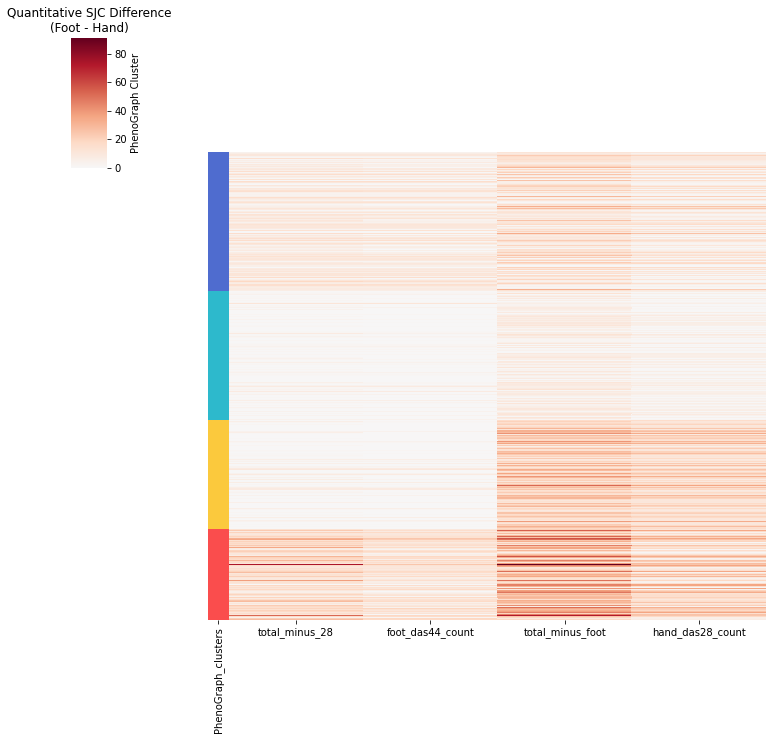

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Sort the dataframe by PhenoGraph_clusters to ensure the heatmap is ordered
metadata_sorted = metadata.sort_values('PhenoGraph_clusters')

# 2. Map Clusters to Colors
# 2. Define your colorblind-friendly palette
pal_colorblind = ['#4F6CCF', '#2db9cc', '#FBC93D', '#FA4D4D']

# 3. Map Clusters to the palette
unique_clusters = metadata_sorted['PhenoGraph_clusters'].unique()
cluster_color_map = {cluster: pal_colorblind[i % len(pal_colorblind)] for i, cluster in enumerate(unique_clusters)}

# Create the color series for the sidebar
row_colors = metadata_sorted['PhenoGraph_clusters'].map(cluster_color_map)

# 3. Prepare the data for the heatmap
heatmap_data = metadata_sorted[['total_minus_28', 'foot_das44_count', 'total_minus_foot', 'hand_das28_count']] # 'JC44_HAND',  ,'JC44_HAND','TJC', 'SJC', 'JC'

# 4. Plotting
plt.figure(figsize=(4, 10))
sns.clustermap(
    heatmap_data,
    row_cluster=False,   # Keep the PhenoGraph sorting
    col_cluster=False,   # No need to cluster the single column
    row_colors=row_colors,
    cmap="RdBu_r",
    annot=False,           # This shows the actual quantitative value in the cell
    #fmt=".1f",            # Format to 1 decimal place
    center=0,             # Ensures 0 is the neutral color
    yticklabels=False #yticklabels=metadata_sorted['PhenoGraph_clusters'] # Label rows by cluster
)

plt.title("Quantitative SJC Difference\n(Foot - Hand)")
plt.ylabel("PhenoGraph Cluster")
plt.show()

## Step 3. Evaluate similarity to original JIP clusters 

Interestingly, we  find 80% similarity with our original clusters. Despite these being identified w/ cluster analysis on 300+ params (joints, lab + demographics). In contrast our simple JIPs found with criteria, use only four features.

In [5]:

def jip_criteria(row):
    """
    Simplified criteria to discern the joint involvement patterns
    
    Here clusters are labeled with an integer, where:
    0 = 'JIP-Foot'
    1 = 'JIP-Oligo'
    2 = 'JIP-Hand'
    3 = 'JIP-Poly'
    """
    if row['total_minus_28'] < 6: 
        if row['hand_das28_count'] < 9:
            # Low hand count and high feet count maps to Foot cluster
            return 1 if row['foot_das44_count'] < 6 else 0
        else: 
            # High hand count maps to Hand cluster
            return 1 if row['total_minus_foot'] < 9 else 2

    # --- BRANCH 2: High Variation (total_minus_28 > 5.0) ---
    else:
        if row['total_minus_28'] < 15:
            # limited joint involvement beside foot maps to Foot cluster
            return 0 if row['total_minus_foot'] < 26 else 3
        else: 
            # Very high variation maps to Poly cluster
            return 3 if row['total_minus_foot'] > 5 else 0


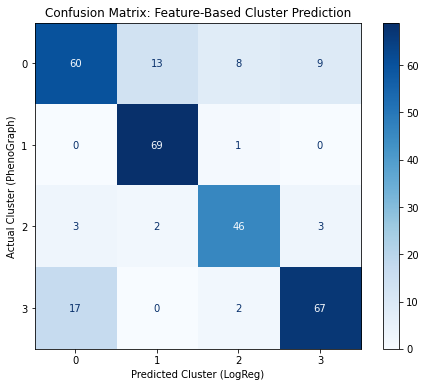

Overall Model Accuracy: 80.67%


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

 
            
y = metadata['PhenoGraph_clusters'] # Original clusters


metadata['pred_cluster'] = metadata.apply(lambda x : jip_criteria(x), axis =1)
y_pred = metadata['pred_cluster'].copy()

# 2. Look at the confusion matrix in test set (last 300 entries were held apart)
cm = confusion_matrix(y[:300], y_pred[:300], labels=[0,1,2,3])

# 3. Plotting
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2,3])

# We use a simple sequential map for clarity of density
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title("Confusion Matrix: Feature-Based Cluster Prediction")
plt.xlabel("Predicted Cluster (LogReg)")
plt.ylabel("Actual Cluster (PhenoGraph)")
plt.show()

# Calculate the overall accuracy
accuracy = accuracy_score(y[:300], y_pred[:300])

print(f"Overall Model Accuracy: {accuracy * 100:.2f}%")

## Step 4. Evaluate clinical outcomes - MTX retention

Our simplified JIPs still show similar trend compared to the original study: where JIP-poly/ JIP-foot are more likely to fail on initial MTX compared to JIP-hand

4039.0
Patients that reach remission in cluster 0: 0.292 0
4071.0
Patients that reach remission in cluster 1: 0.218 309
4045.0
Patients that reach remission in cluster 2: 0.163 210
3976.0
Patients that reach remission in cluster 3: 0.299 155


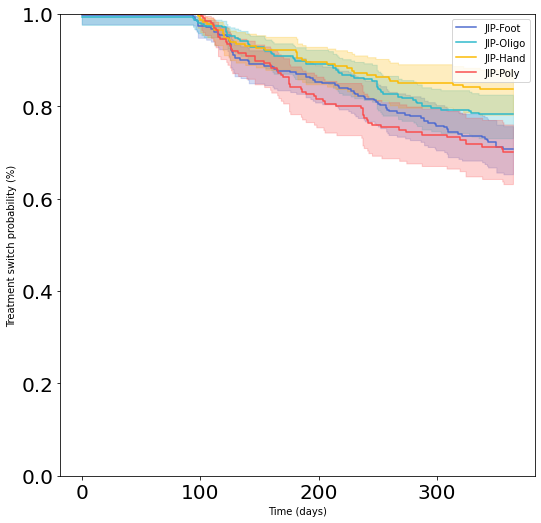

In [16]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import matplotlib 
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
ax = plt.subplot(111)

metadata['pred_cluster'] = y_pred
metadata['pred_cluster'] = metadata.apply(lambda x : jip_criteria(x), axis =1)

df_response = pd.read_csv('data/Leiden_EHR_survival_table.csv')
df_response = df_response[df_response['MTX-starter']==True].copy() # Subset on MTX-starters

# add predicted cluster to survival table
d_patnr_cluster = dict(zip(metadata['pseudoId'], metadata['pred_cluster']))
df_response['New_cluster'] = df_response['pseudoId'].apply(lambda x : d_patnr_cluster[x])

FOLLOWUP= 365 

pal_colorblind = ['#4F6CCF', '#2db9cc', '#fcba03', '#FA4D4D',   "#7a4da4", "#a67c73", "#FF0000FF", "#CCFF00FF", "#49BA2B", "#0066FFFF", "#CC00FFFF", '#FF9595'];

kmf = KaplanMeierFitter() 

fig = plt.gcf()
fig.set_size_inches(8.5, 8.5)
ix = 0

# Set y-axis limits
plt.ylim(0, 1)

for name, grouped_df in df_response.groupby('New_cluster'):
    #print(grouped_df['RANDO'].unique())
    kmf.fit(grouped_df["time"], grouped_df["event_1y"], label=name, timeline=range(0, FOLLOWUP, 1)) # , timeline=range(0, 365+62, 1)
    kmf.plot_survival_function(ax=ax, color=pal_colorblind[ix])
    print(grouped_df["time"].max())

    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Treatment switch probability (%)')
    ax.set_ylim([0, 1])

    df = kmf.event_table.copy()
    df = df.reset_index()
    
    # calculate final patients that stay with baseline by hand (positive control)
    print('Patients that reach remission in cluster %s: %.3f' % (name, 1 - kmf.survival_function_.iloc[-1].values[0]),  round(kmf.survival_function_.iloc[-1].values[0]*len(df_response[((df_response['time']>=0) & (df_response['Cluster']==name) )]))) # (df_response['time']>=0) &
    ix +=1 
plt.legend(['JIP-Foot', 'JIP-Oligo', 'JIP-Hand', 'JIP-Poly'])

### 4.2 Check also clinical outcome : Remission

For remission we also note a similar pattern

4045.0
Patients that reach remission in cluster 0: 0.421 0
3792.0
Patients that reach remission in cluster 1: 0.482 108
4045.0
Patients that reach remission in cluster 2: 0.516 60
3976.0
Patients that reach remission in cluster 3: 0.286 118


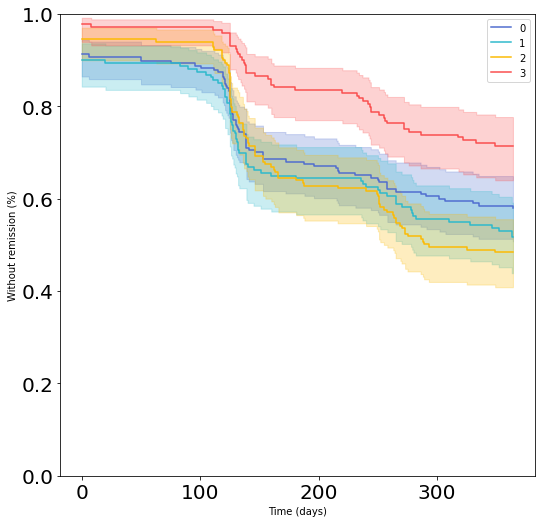

In [15]:

import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
import matplotlib 
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 
ax = plt.subplot(111)

FOLLOWUP= 365 #365+62
df_subEAC = pd.read_csv('data/Leiden_EHR_survival_Remission.csv', sep=';')
d_patnr_cluster = dict(zip(metadata['pseudoId'], metadata['pred_cluster']))
df_subEAC['New_cluster'] = df_subEAC['pseudoId'].apply(lambda x : d_patnr_cluster[x])


pal_colorblind = ['#4F6CCF', '#2db9cc', '#fcba03', '#FA4D4D',   "#7a4da4", "#a67c73", "#FF0000FF", "#CCFF00FF", "#49BA2B", "#0066FFFF", "#CC00FFFF", '#FF9595'];

kmf = KaplanMeierFitter() # , timeline=range(1, FOLLOWUP, 1)

fig = plt.gcf()
fig.set_size_inches(8.5, 8.5)
ix = 0

# Set y-axis limits
plt.ylim(0, 1)

for name, grouped_df in df_subEAC.groupby('New_cluster'):
    #print(grouped_df['RANDO'].unique())
    kmf.fit(grouped_df["time_till_Rem"], grouped_df["event_1y_Rem"], label=name, timeline=range(0, FOLLOWUP, 1)) # , timeline=range(0, 365+62, 1)
    kmf.plot_survival_function(ax=ax, color=pal_colorblind[ix])
    print(grouped_df["time_till_Rem"].max())

    ax.set_xlabel('Time (days)')
    ax.set_ylabel('Without remission (%)')
    ax.set_ylim([0, 1])

    df = kmf.event_table.copy()
    df = df.reset_index()
    
    # calculate final patients that stay with baseline by hand (positive control)
    #final = (len(df_response[((df_response['event']==True) & (df_response['Cluster']==name) & (df_response['time']>FOLLOWUP))]) + len(df_response[((df_response['event']==False) & (df_response['Cluster']==name))]))/len(df_response[((df_response['Cluster']==name))])
    #print('Patients that stay with treatment in cluster %s: %.2f' % (name, final), len(df_response[((df_response['Cluster']==name) & (df_response['time']<FOLLOWUP))]))
    print('Patients that reach remission in cluster %s: %.3f' % (name, 1 - kmf.survival_function_.iloc[-1].values[0]),  round(kmf.survival_function_.iloc[-1].values[0]*len(df_subEAC[((df_subEAC['time_till_Rem']>=0) & (df_subEAC['Cluster']==name) )]))) # (df_response['time']>=0) &
    ix +=1 
    

## check gestalt

In [7]:
import pandas as pd
import sys
sys.path.append(r'src/')
import MannequinFunctions as func
import matplotlib.pyplot as plt
import importlib as imp
imp.reload(func)

# Import mannequin information
df_man = pd.read_csv('data/Leiden_EHR_joints_mannequin.csv', sep='|')
df_man = df_man[[col for col in df_man.columns if '_negative' not in col]]


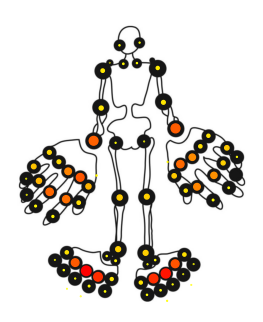

In [8]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Create a custom color palette from black to red
custom_palette = sns.color_palette("dark:red", n_colors=256)
custom_cmap = LinearSegmentedColormap.from_list("custom", custom_palette)


CLUSTER = 0

l_pat = set(metadata[metadata['pred_cluster']==CLUSTER]['pseudoId'])
df_man['index'] = metadata['sample'].copy()

df_sjc = df_man[df_man['pseudoId'].isin(l_pat)].copy()
df_tjc = df_sjc.copy()
l_swollen = [col for col in df_man.columns if 'Zwelling_' in col]
l_swollen.append('pseudoId')

l_tender = [col for col in df_man.columns if 'Pijn_' in col]
l_tender.append('pseudoId')

df_sjc = df_sjc[l_swollen]
df_sjc.columns = [col.split("_")[1] if "_" in col else col for col in df_sjc.columns  ]

df_tjc = df_tjc[l_tender]
df_tjc.columns = [col.split("_")[1] if "_" in col else col for col in df_tjc.columns  ]

df_total = df_sjc.copy()# pd.concat([df_sjc, df_tjc]).groupby('pseudoId', as_index=False).mean()

#create scatterplot (toDo: for both big & small joints)
l_col = [col for col in df_total.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'index']]
df_plot = pd.DataFrame(df_total[l_col].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
df_plot['s'] = df_plot['s'] * df_plot['value']

# Visualize gestalt
im = plt.imread('figures/template/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='autumn_r') # cool
#plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, color='red') # cool


fig = plt.gcf()
plt.axis('off')
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
fig.set_dpi(100)

sns.set(rc={'axes.facecolor':'#0000FF', 'figure.facecolor':(0,0,0,0), "savefig.facecolor": (0, 0, 0, 0)})  # blue  with alpha = 20%'})
plt.show()

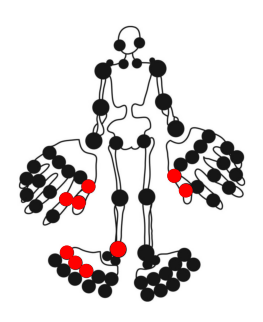

In [11]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Create a custom color palette from black to red
custom_palette = sns.color_palette("dark:red", n_colors=256)
custom_cmap = LinearSegmentedColormap.from_list("custom", custom_palette)


CLUSTER = 0

l_pat = [metadata[metadata['pred_cluster']==CLUSTER]['pseudoId'].iloc[1]]
df_man['index'] = metadata['sample'].copy()

df_sjc = df_man[df_man['pseudoId'].isin(l_pat)].copy()
df_tjc = df_sjc.copy()
l_swollen = [col for col in df_man.columns if 'Zwelling_' in col]
l_swollen.append('pseudoId')

l_tender = [col for col in df_man.columns if 'Pijn_' in col]
l_tender.append('pseudoId')

df_sjc = df_sjc[l_swollen]
df_sjc.columns = [col.split("_")[1] if "_" in col else col for col in df_sjc.columns  ]

df_tjc = df_tjc[l_tender]
df_tjc.columns = [col.split("_")[1] if "_" in col else col for col in df_tjc.columns  ]

# total = Swollen
df_total = df_tjc.copy()# pd.concat([df_sjc, df_tjc]).groupby('pseudoId', as_index=False).mean()

#create scatterplot (toDo: for both big & small joints)
l_col = [col for col in df_total.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'index']]
df_plot = pd.DataFrame(df_total[l_col].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
df_plot['s'] = df_plot['s'] * df_plot['value']

# Visualize gestalt
im = plt.imread('figures/template/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='autumn_r') # cool
#plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, color='red') # cool


fig = plt.gcf()
plt.axis('off')
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
fig.set_dpi(100)

sns.set(rc={'axes.facecolor':'#0000FF', 'figure.facecolor':(0,0,0,0), "savefig.facecolor": (0, 0, 0, 0)})  # blue  with alpha = 20%'})
plt.show()

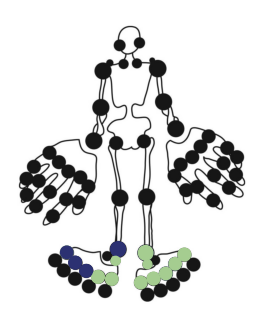

In [52]:
l_col_feet = l_t_feet_44 + l_s_feet_44 #+ ['onderste_sprong']

# total = Swollen
df_total = df_man[df_man['pseudoId'].isin(l_pat)].copy() # pd.concat([df_sjc, df_tjc]).groupby('pseudoId', as_index=False).mean()
#df_total[l_col_min28] = 1

#create scatterplot (toDo: for both big & small joints)
l_col = [col for col in df_total.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'index']]
df_plot = pd.DataFrame(df_total[df_total[l_col_feet].isin([0,1])].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
#df_plot['s'] = df_plot['s'] * df_plot['value']

# Visualize gestalt
im = plt.imread('figures/template/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='crest') # cool


fig = plt.gcf()
plt.axis('off')
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
fig.set_dpi(100)

sns.set(rc={'axes.facecolor':'#0000FF', 'figure.facecolor':(0,0,0,0), "savefig.facecolor": (0, 0, 0, 0)})  # blue  with alpha = 20%'})
plt.show()

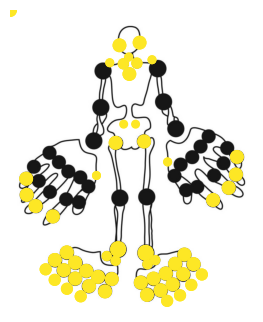

In [39]:
l_col_min28 = [col for col in df_man.columns if col not in l_DAS28]

# total = Swollen
df_total = df_man[df_man['pseudoId'].isin(l_pat)].copy() # pd.concat([df_sjc, df_tjc]).groupby('pseudoId', as_index=False).mean()
df_total[l_col_min28] = 1

#create scatterplot (toDo: for both big & small joints)
l_col = [col for col in df_total.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'index']]
df_plot = pd.DataFrame(df_total[df_total[l_col_min28].isin([0,1])].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
#df_plot['s'] = df_plot['s'] * df_plot['value']

# Visualize gestalt
im = plt.imread('figures/template/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='viridis_r') # cool
#plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, color='red') # cool


fig = plt.gcf()
plt.axis('off')
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
fig.set_dpi(100)

sns.set(rc={'axes.facecolor':'#0000FF', 'figure.facecolor':(0,0,0,0), "savefig.facecolor": (0, 0, 0, 0)})  # blue  with alpha = 20%'})
plt.show()

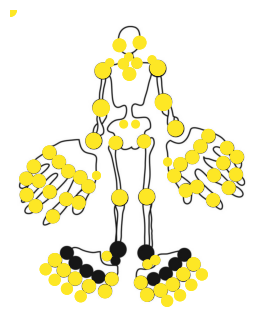

In [49]:
l_col_minFoot = [col for col in df_man.columns if col not in l_col_feet]

# total = Swollen
df_total = df_man[df_man['pseudoId'].isin(l_pat)].copy() # pd.concat([df_sjc, df_tjc]).groupby('pseudoId', as_index=False).mean()
df_total[l_col_minFoot] = 1

#create scatterplot (toDo: for both big & small joints)
l_col = [col for col in df_total.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'index']]
df_plot = pd.DataFrame(df_total[df_total[l_col_minFoot].isin([0,1])].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
#df_plot['s'] = df_plot['s'] * df_plot['value']

# Visualize gestalt
im = plt.imread('figures/template/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='viridis_r') # cool
#plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, color='red') # cool


fig = plt.gcf()
plt.axis('off')
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
fig.set_dpi(100)

sns.set(rc={'axes.facecolor':'#0000FF', 'figure.facecolor':(0,0,0,0), "savefig.facecolor": (0, 0, 0, 0)})  # blue  with alpha = 20%'})
plt.show()

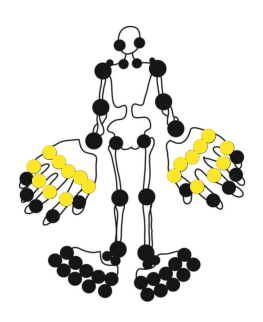

In [47]:


l_col_hand_das28 = l_t_mcp + l_s_mcp + l_t_pip + l_s_pip

# total = Swollen
df_total = df_man[df_man['pseudoId'].isin(l_pat)].copy() # pd.concat([df_sjc, df_tjc]).groupby('pseudoId', as_index=False).mean()
df_total[l_col_hand_das28] = 1

#create scatterplot (toDo: for both big & small joints)
l_col = [col for col in df_total.columns if col not in ['pseudoId', 'patnr','FirstConsult', 'index']]
df_plot = pd.DataFrame(df_total[df_total[l_col_hand_das28].isin([0,1])].mean().T)
df_plot= df_plot.reset_index()
df_plot.columns = ['feature', 'value']
df_plot['x'], df_plot['y'], df_plot['s'] = zip(*df_plot['feature'].apply(lambda x : func.get_mannequin_coord(x)))
#df_plot['s'] = df_plot['s'] * df_plot['value']

# Visualize gestalt
im = plt.imread('figures/template/Mannequin_large_old.jpg')
implot = plt.imshow(im)
plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, c=df_plot.value, cmap='viridis_r') # cool
#plt.scatter(df_plot.x, df_plot.y, s=df_plot.s, color='red') # cool


fig = plt.gcf()
plt.axis('off')
#plt.text(450, 1, r'Cluster %s' % str(CLUSTER+1), fontsize=15)
fig.set_dpi(100)

sns.set(rc={'axes.facecolor':'#0000FF', 'figure.facecolor':(0,0,0,0), "savefig.facecolor": (0, 0, 0, 0)})  # blue  with alpha = 20%'})
plt.show()